In [1]:
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import numpy as np
import random
from IPython.display import HTML

m0 = 5
m = 3
N=5


def generate_ba_graph(final_size, m_initial, m_edges):
    """
    Generates a Barabasi-Albert graph manually to demonstrate the logic.
    """
    G = nx.complete_graph(m_initial)

    repeated_nodes = []
    for node in G.nodes():
        for _ in range(G.degree(node)):
            repeated_nodes.append(node)

    for new_node in range(m_initial, final_size):
        targets = set()
        while len(targets) < m_edges:
            target = random.choice(repeated_nodes)
            targets.add(target)
            
        G.add_node(new_node)
        for target in targets:
            G.add_edge(new_node, target)
            repeated_nodes.append(new_node)
            repeated_nodes.append(target)
            
    return G

final_graph = generate_ba_graph(N, m0, m)

fig, ax = plt.subplots(figsize=(7,7))
G_anim = nx.complete_graph(m0)
pos = nx.spring_layout(G_anim)

def update(frame):
    ax.clear()
    if frame >= m0:
        new_node = frame
        targets = set()
        repeated_nodes = []
        for node in G_anim.nodes():
            for _ in range(G_anim.degree(node)):
                repeated_nodes.append(node)
    
        if repeated_nodes:
            while len(targets) < m:
                targets.add(random.choice(repeated_nodes))
        else:
            targets = list(G_anim.nodes())[:m]
        G_anim.add_node(new_node)
        for t in targets:
            G_anim.add_edge(new_node, t)
    
    node_sizes = [50 + 15* G_anim.degree(n) for n in G_anim.nodes()]
    global pos
    pos = nx.spring_layout(G_anim, pos=pos, iterations=3, seed=42)
    
    nx.draw(G_anim, pos, ax=ax, 
            node_size=node_sizes,
            node_color='skyblue', 
            edge_color='gray', 
            alpha=0.8)
            
    ax.set_title(f"Time t={frame} | Nodes: {len(G_anim)}", fontsize=15)

ani = animation.FuncAnimation(fig, update, frames=range(m0, m0 + 50), interval=100)

plt.close()
HTML(ani.to_jshtml())

## Exercise 3

Running 50 simulations...


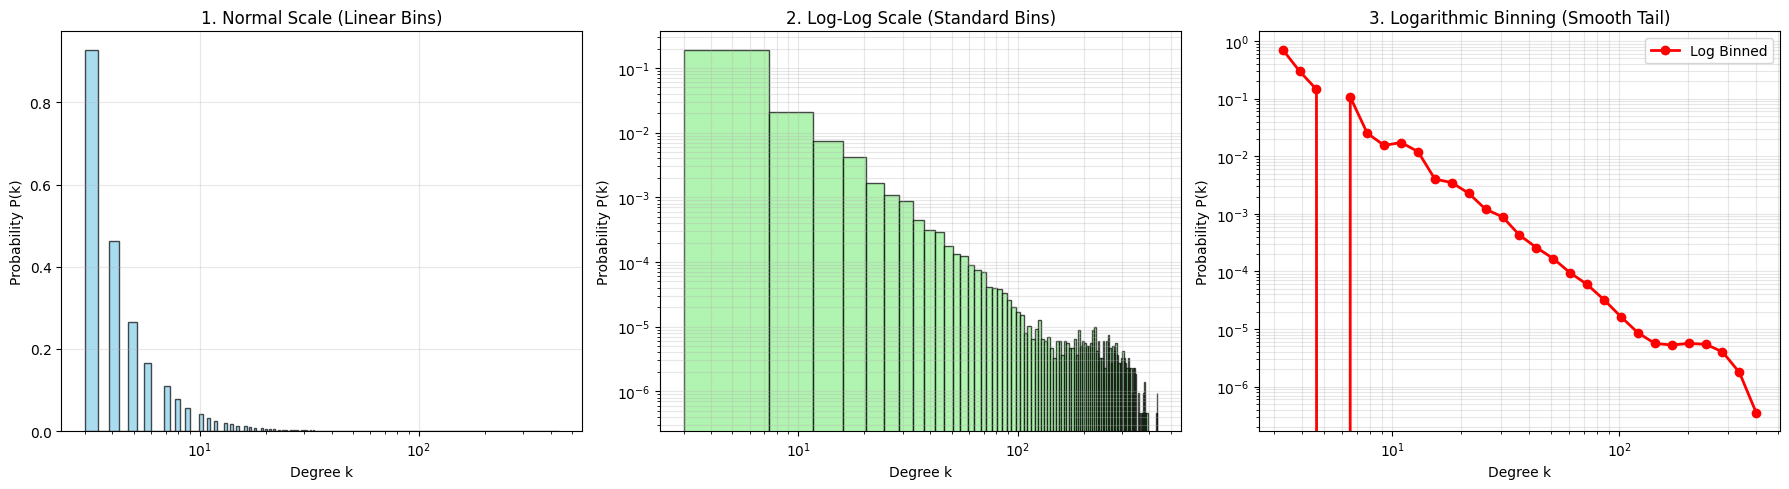

In [2]:
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
import random

t_final = 10000
m0 = 10
m = 3
num_simulations = 50

def run_ba_simulation(final_size, m_initial, m_edges):
    G = nx.complete_graph(m_initial)
    repeated_nodes = []
    for node in G.nodes():
        for _ in range(G.degree(node)):
            repeated_nodes.append(node)
            
    for new_node in range(m_initial, final_size):
        targets = set()
        while len(targets) < m_edges:
            targets.add(random.choice(repeated_nodes))
            
        G.add_node(new_node)
        for target in targets:
            G.add_edge(new_node, target)
            repeated_nodes.append(new_node)
            repeated_nodes.append(target)
            
    return [d for n, d in G.degree()]

print(f"Running {num_simulations} simulations...")
all_degrees = []
for i in range(num_simulations):
    degrees = run_ba_simulation(t_final, m0, m)
    all_degrees.extend(degrees)

plt.figure(figsize=(18, 5))

plt.subplot(1, 3, 1)
plt.hist(all_degrees, bins=1000, density=True, color='skyblue', edgecolor='black', alpha=0.7)
plt.title("1. Normal Scale (Linear Bins)")
plt.xlabel("Degree k")
plt.ylabel("Probability P(k)")
plt.xscale('log')
plt.grid(True, alpha=0.3)

plt.subplot(1, 3, 2)
plt.hist(all_degrees, bins=100, density=True, color='lightgreen', edgecolor='black', alpha=0.7)
plt.xscale('log')
plt.yscale('log')
plt.title("2. Log-Log Scale (Standard Bins)")
plt.xlabel("Degree k")
plt.ylabel("Probability P(k)")
plt.grid(True, which="both", alpha=0.3)

plt.subplot(1, 3, 3)

min_k = min(all_degrees)
max_k = max(all_degrees)
log_bins = np.logspace(np.log10(min_k), np.log10(max_k), 30)

counts, bin_edges = np.histogram(all_degrees, bins=log_bins, density=True)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

plt.plot(bin_centers, counts, 'o-', color='red', linewidth=2, markersize=6, label='Log Binned')

plt.xscale('log')
plt.yscale('log')
plt.title("3. Logarithmic Binning (Smooth Tail)")
plt.xlabel("Degree k")
plt.ylabel("Probability P(k)")
plt.legend()
plt.grid(True, which="both", alpha=0.3)

plt.tight_layout()
plt.show()

Generating plots for 10 simulations...


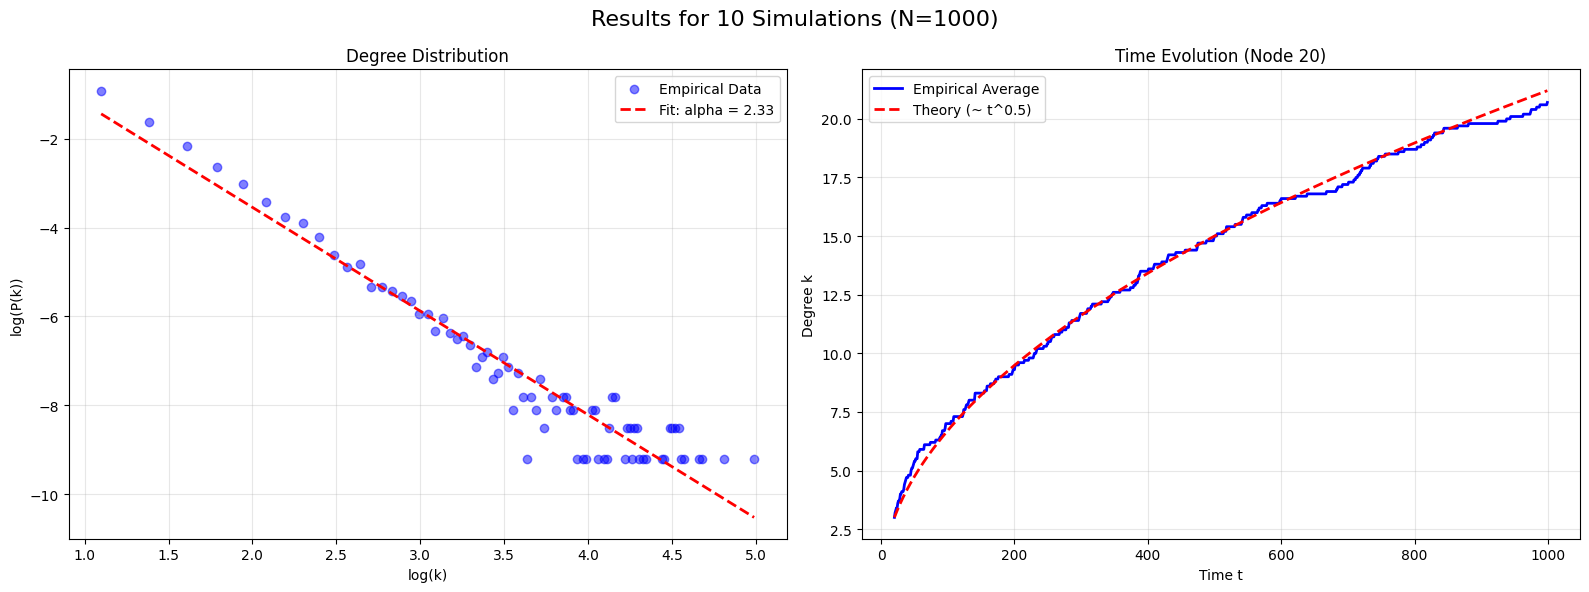

Generating plots for 50 simulations...


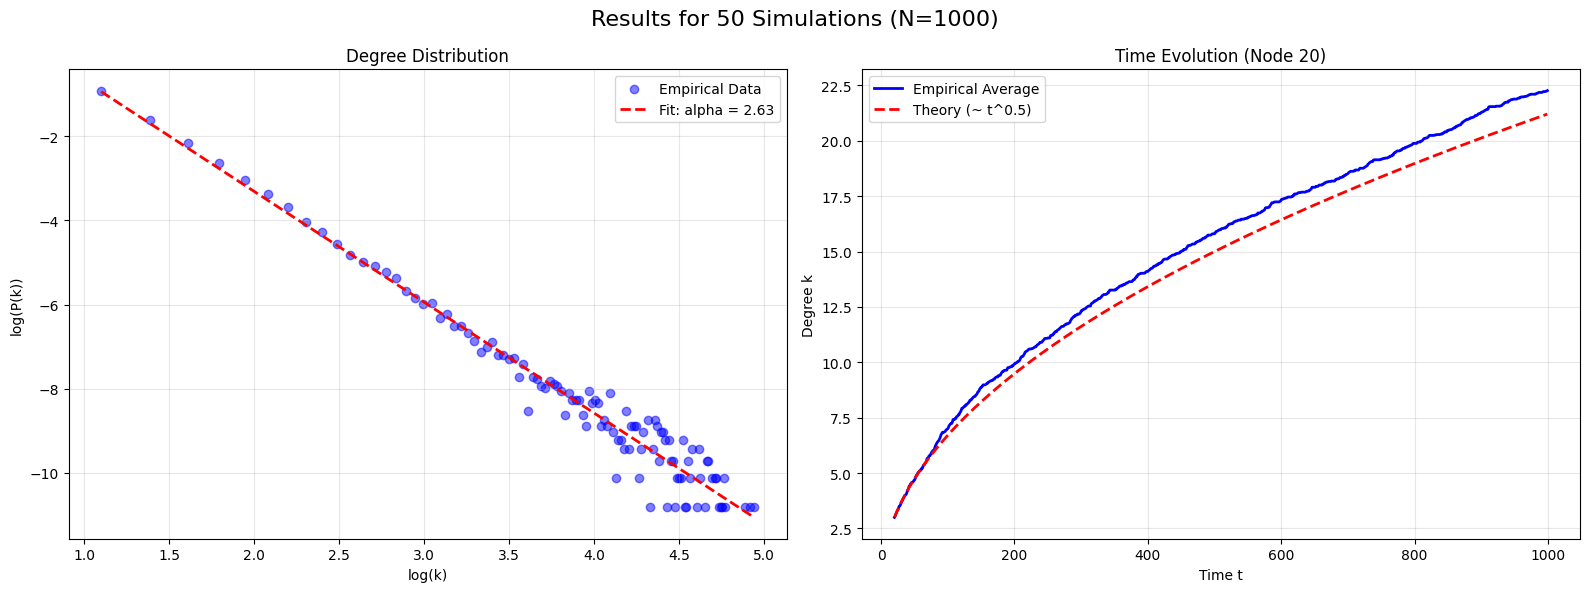

Generating plots for 100 simulations...


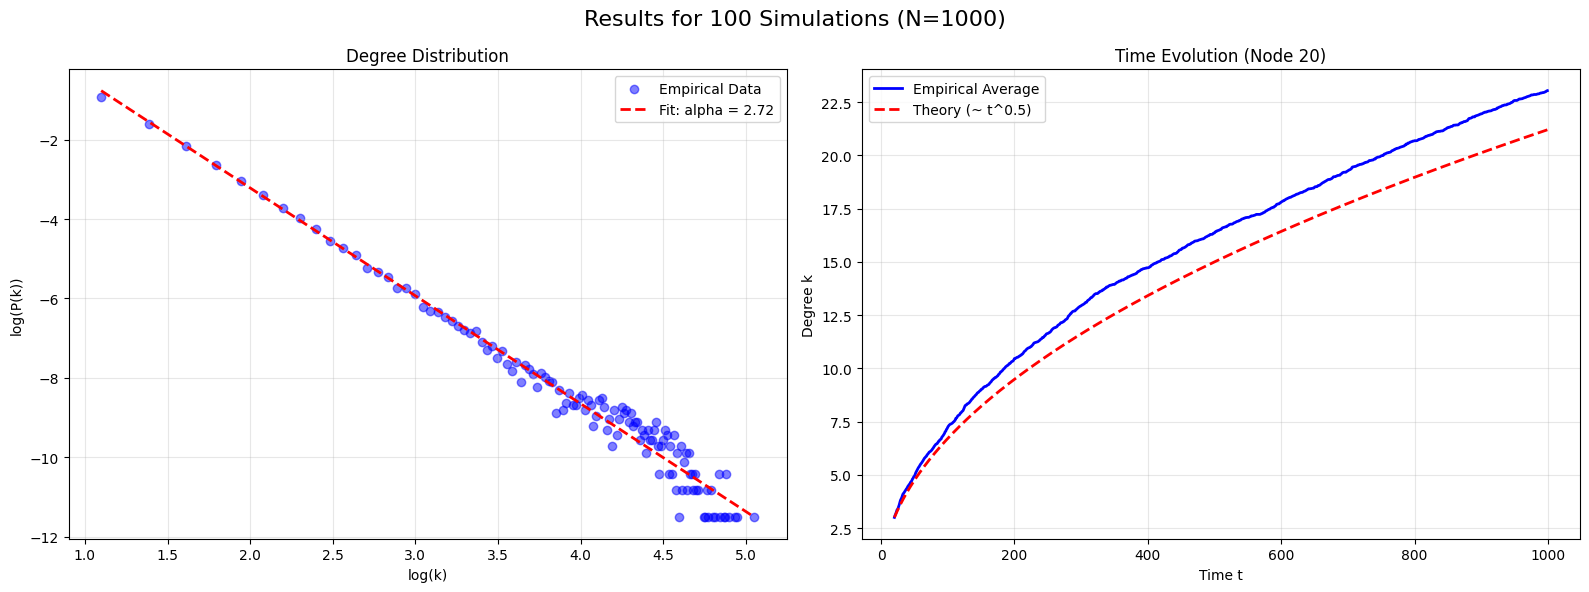

Generating plots for 200 simulations...


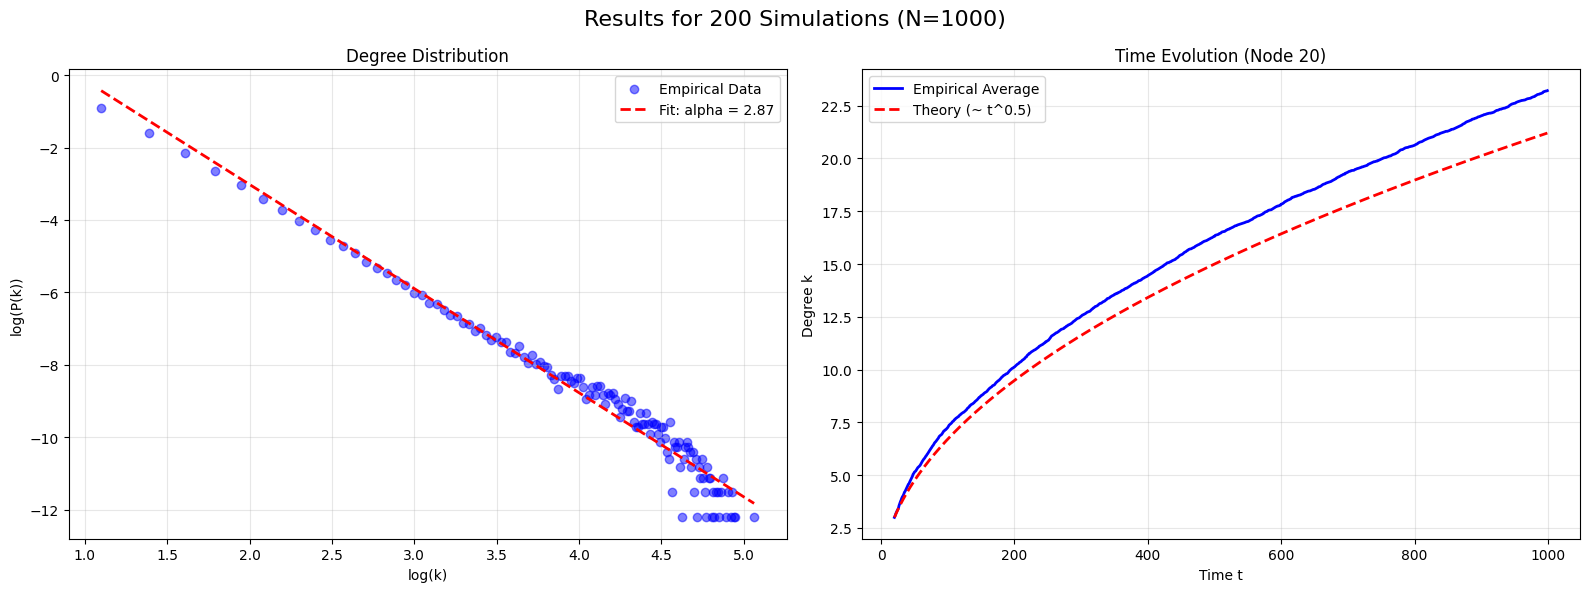

Generating plots for 400 simulations...


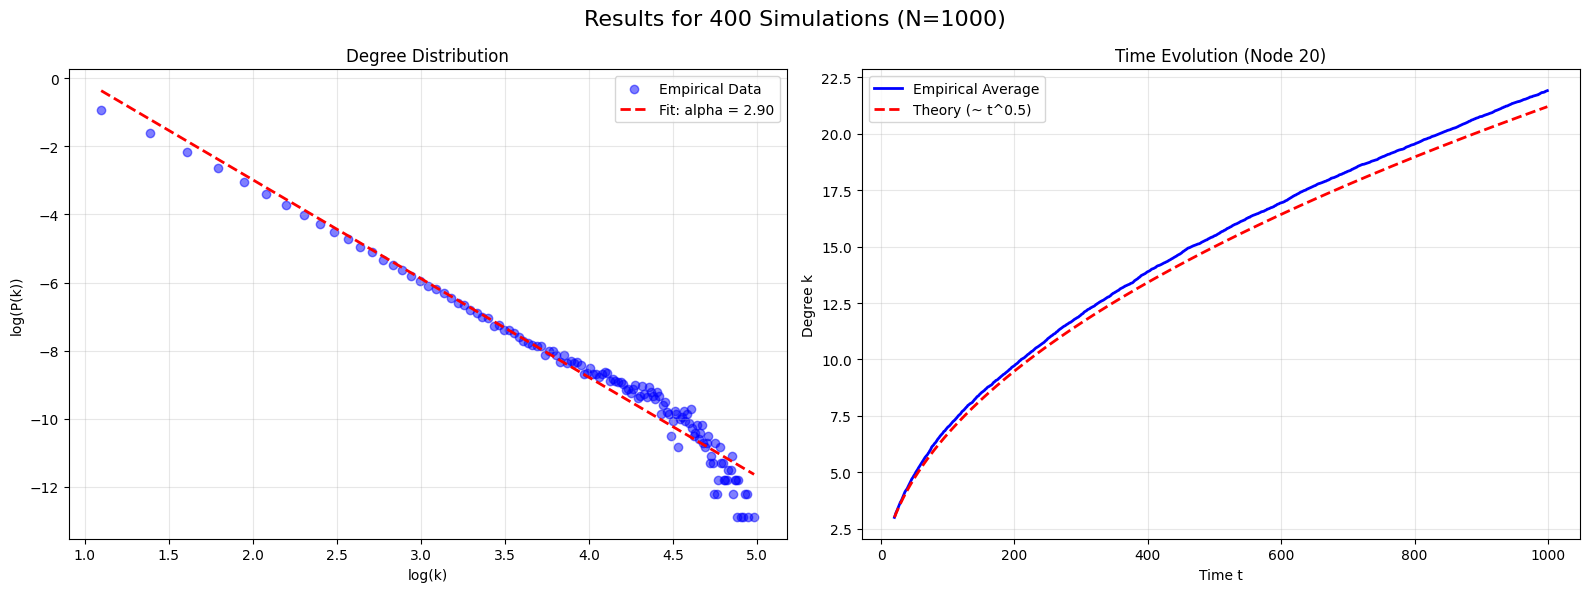

In [3]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
import random

N = 1000
m0 = 5
m = 3
simulation_counts = [10, 50, 100, 200, 400] 

def get_all_degrees_ba(final_size, m_initial, m_edges):
    """Runs a BA simulation and returns a list of all final degrees."""
    G = nx.complete_graph(m_initial)
    repeated_nodes = []
    for node in G.nodes():
        for _ in range(G.degree(node)):
            repeated_nodes.append(node)
            
    for new_node in range(m_initial, final_size):
        targets = set()
        while len(targets) < m_edges:
            targets.add(random.choice(repeated_nodes))
        G.add_node(new_node)
        for target in targets:
            G.add_edge(new_node, target)
            repeated_nodes.append(new_node)
            repeated_nodes.append(target)
    return [d for n, d in G.degree()]

def track_node_history(final_size, m_initial, m_edges, tracked_node_id):
    """Runs simulation and tracks ONE node's degree over time."""
    G = nx.complete_graph(m_initial)
    history = []
    repeated_nodes = []
    for node in G.nodes():
        for _ in range(G.degree(node)):
            repeated_nodes.append(node)
            
    for t in range(m_initial, final_size):
        targets = set()
        while len(targets) < m_edges:
            targets.add(random.choice(repeated_nodes))
        G.add_node(t)
        for target in targets:
            G.add_edge(t, target)
            repeated_nodes.append(t)
            repeated_nodes.append(target)
        
        if t >= tracked_node_id:
            history.append(G.degree(tracked_node_id))
            
    return history

for sim_count in simulation_counts:
    print(f"Generating plots for {sim_count} simulations...")
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    fig.suptitle(f'Results for {sim_count} Simulations (N={N})', fontsize=16)

    aggregated_degrees = []
    for i in range(sim_count):
        aggregated_degrees.extend(get_all_degrees_ba(N, m0, m))

    degree_counts = np.unique(aggregated_degrees, return_counts=True)
    k_values = degree_counts[0]
    pk_values = degree_counts[1] / sum(degree_counts[1])

    mask = pk_values > 0
    log_k = np.log(k_values[mask])
    log_pk = np.log(pk_values[mask])

    slope, intercept = np.polyfit(log_k, log_pk, 1)
    alpha_empirical = -slope

    ax1.scatter(log_k, log_pk, color='blue', alpha=0.5, label='Empirical Data')
    ax1.plot(log_k, slope * log_k + intercept, color='red', linestyle='--', linewidth=2, 
             label=f'Fit: alpha = {alpha_empirical:.2f}')
    ax1.set_title(f"Degree Distribution")
    ax1.set_xlabel("log(k)")
    ax1.set_ylabel("log(P(k))")
    ax1.legend()
    ax1.grid(True, alpha=0.3)


    node_to_track = 20
    all_histories = []
    for i in range(sim_count):
        h = track_node_history(N, m0, m, node_to_track)
        if h: all_histories.append(h)

    if all_histories:
        min_length = min(len(h) for h in all_histories)
        all_histories = [h[:min_length] for h in all_histories]
        avg_history = np.mean(all_histories, axis=0)

        time_axis = np.arange(node_to_track, node_to_track + len(avg_history))
        theoretical_k = m * (time_axis / node_to_track)**0.5

        ax2.plot(time_axis, avg_history, label=f'Empirical Average', color='blue', linewidth=2)
        ax2.plot(time_axis, theoretical_k, label='Theory (~ t^0.5)', color='red', linestyle='--', linewidth=2)
        ax2.set_title(f"Time Evolution (Node {node_to_track})")
        ax2.set_xlabel("Time t")
        ax2.set_ylabel("Degree k")
        ax2.legend()
        ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

 P6.3 Check with simulations result obtained for model A. [1.5P]

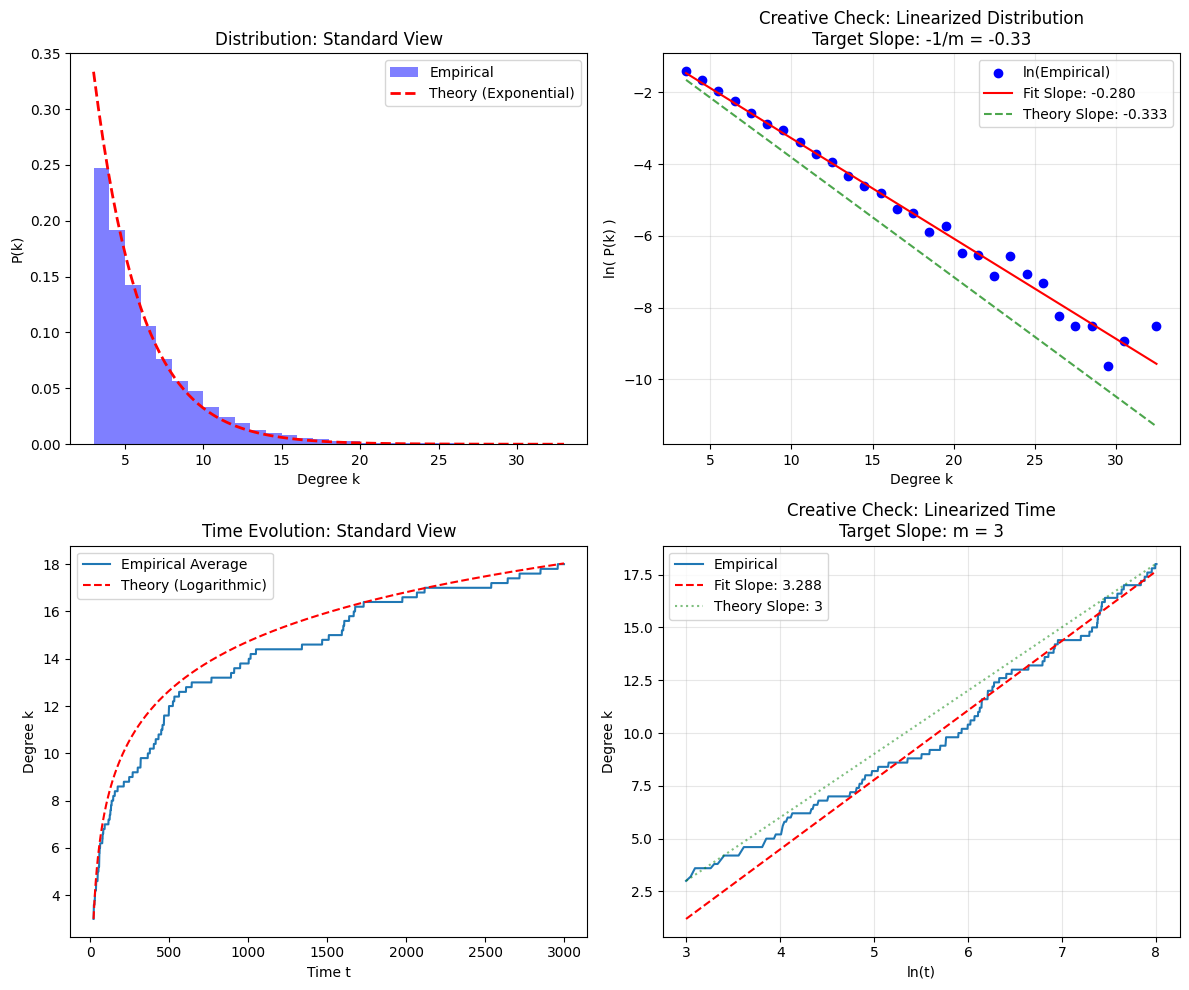

In [4]:
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
import random
from scipy.stats import linregress

N = 3000
m0 = 5
m = 3
num_simulations = 5
node_to_track = 20


def generate_model_a_data(final_size, m_initial, m_edges, track_id):
    G = nx.complete_graph(m_initial)
    history = []
    
    nodes_list = list(G.nodes())
    
    for t in range(m_initial, final_size):
        targets = random.sample(nodes_list, m_edges)
        
        G.add_node(t)
        nodes_list.append(t)
        
        for target in targets:
            G.add_edge(t, target)
            
        if t >= track_id:
            history.append(G.degree(track_id))
            
    return [d for n, d in G.degree()], history

all_degrees = []
all_histories = []

for i in range(num_simulations):
    degs, hist = generate_model_a_data(N, m0, m, node_to_track)
    all_degrees.extend(degs)
    all_histories.append(hist)

plt.figure(figsize=(12, 10))

plt.subplot(2, 2, 1)
counts, bins, _ = plt.hist(all_degrees, bins=30, density=True, alpha=0.5, color='blue', label='Empirical')
k_smooth = np.linspace(min(bins), max(bins), 100)
p_theory = (np.exp(1)/m) * np.exp(-k_smooth/m) # Exact theory from P6.1
plt.plot(k_smooth, p_theory, 'r--', lw=2, label='Theory (Exponential)')
plt.title("Distribution: Standard View")
plt.xlabel("Degree k")
plt.ylabel("P(k)")
plt.legend()

plt.subplot(2, 2, 2)
y_vals = counts
x_vals = 0.5 * (bins[1:] + bins[:-1])
mask = y_vals > 0
x_fit = x_vals[mask]
y_fit = np.log(y_vals[mask])

slope, intercept, r_val, _, _ = linregress(x_fit, y_fit)

plt.scatter(x_fit, y_fit, color='blue', label='ln(Empirical)')
plt.plot(x_fit, slope * x_fit + intercept, 'r-', label=f'Fit Slope: {slope:.3f}')
plt.plot(x_fit, -1/m * x_fit + intercept, 'g--', alpha=0.7, label=f'Theory Slope: {-1/m:.3f}')

plt.title(f"Creative Check: Linearized Distribution\nTarget Slope: -1/m = {-1/m:.2f}")
plt.xlabel("Degree k")
plt.ylabel("ln( P(k) )")
plt.legend()
plt.grid(True, alpha=0.3)

min_len = min(len(h) for h in all_histories)
avg_hist = np.mean([h[:min_len] for h in all_histories], axis=0)
time_steps = np.arange(node_to_track, node_to_track + len(avg_hist))

plt.subplot(2, 2, 3)
plt.plot(time_steps, avg_hist, label='Empirical Average')
plt.plot(time_steps, m * np.log(time_steps/node_to_track) + m, 'r--', label='Theory (Logarithmic)')
plt.title("Time Evolution: Standard View")
plt.xlabel("Time t")
plt.ylabel("Degree k")
plt.legend()

plt.subplot(2, 2, 4)
log_time = np.log(time_steps)

slope_t, intercept_t, r_val_t, _, _ = linregress(log_time, avg_hist)

plt.plot(log_time, avg_hist, label='Empirical')
plt.plot(log_time, slope_t * log_time + intercept_t, 'r--', label=f'Fit Slope: {slope_t:.3f}')
plt.plot(log_time, m * log_time + (m - m*np.log(node_to_track)), 'g:', alpha=0.5, label=f'Theory Slope: {m}')

plt.title(f"Creative Check: Linearized Time\nTarget Slope: m = {m}")
plt.xlabel("ln(t)")
plt.ylabel("Degree k")
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## P6.4 Check with simulations result obtained for model B. [1.5P]

Theoretical Slope: 0.0200
Measured Slope:    0.0219


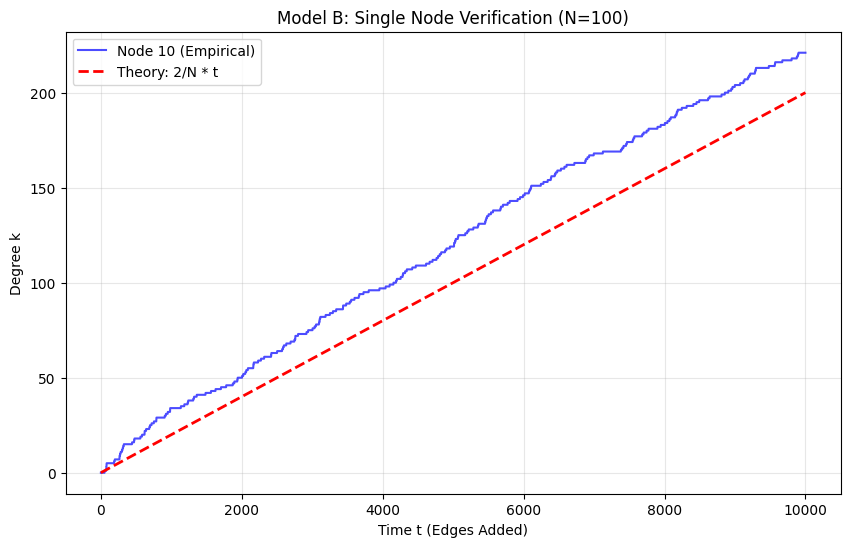

In [5]:
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
import random
from scipy.stats import linregress

N = 100
T_steps = 10000
node_to_track = 10


G = nx.MultiGraph() 
G.add_nodes_from(range(N))

history = []

u, v = random.sample(range(N), 2)
G.add_edge(u, v)
repeated_nodes = [u, v]

for t in range(T_steps):
    source = random.randint(0, N - 1)
    target = random.choice(repeated_nodes)
    G.add_edge(source, target)
    repeated_nodes.extend([source, target])
    history.append(G.degree(node_to_track))

time_axis = np.arange(1, len(history) + 1)
theoretical_line = (2 / N) * time_axis

plt.figure(figsize=(10, 6))

plt.plot(time_axis, history, color='blue', alpha=0.7, label=f'Node {node_to_track} (Empirical)')

plt.plot(time_axis, theoretical_line, 'r--', linewidth=2, label='Theory: 2/N * t')

plt.title(f"Model B: Single Node Verification (N={N})")
plt.xlabel("Time t (Edges Added)")
plt.ylabel("Degree k")
plt.legend()
plt.grid(True, alpha=0.3)

slope, intercept, _, _, _ = linregress(time_axis, history)
print(f"Theoretical Slope: {2/N:.4f}")
print(f"Measured Slope:    {slope:.4f}")

plt.show()

<>:40: SyntaxWarning: invalid escape sequence '\m'
<>:40: SyntaxWarning: invalid escape sequence '\s'
<>:40: SyntaxWarning: invalid escape sequence '\m'
<>:40: SyntaxWarning: invalid escape sequence '\s'
C:\Users\Bartus\AppData\Local\Temp\ipykernel_7748\1381654597.py:40: SyntaxWarning: invalid escape sequence '\m'
  plt.plot(x, p, 'k--', linewidth=2, label=f'Gaussian Fit\n($\mu={mu:.1f}, \sigma={std:.1f}$)')
C:\Users\Bartus\AppData\Local\Temp\ipykernel_7748\1381654597.py:40: SyntaxWarning: invalid escape sequence '\s'
  plt.plot(x, p, 'k--', linewidth=2, label=f'Gaussian Fit\n($\mu={mu:.1f}, \sigma={std:.1f}$)')


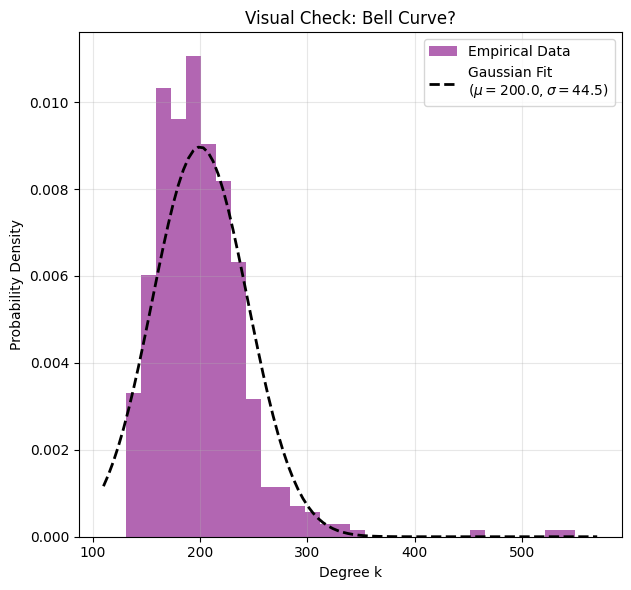

In [6]:
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
import random
import scipy.stats as stats

N = 100
T_steps = 10000
num_simulations = 5

def get_model_b_degrees(n_nodes, t_steps):
    G = nx.MultiGraph()
    G.add_nodes_from(range(n_nodes))
    u, v = random.sample(range(n_nodes), 2)
    G.add_edge(u, v)
    repeated_nodes = [u, v]
    
    for _ in range(t_steps):
        source = random.randint(0, n_nodes - 1)
        target = random.choice(repeated_nodes)
        
        G.add_edge(source, target)
        repeated_nodes.extend([source, target])
        
    return [d for n, d in G.degree()]

all_degrees = []
for _ in range(num_simulations):
    all_degrees.extend(get_model_b_degrees(N, T_steps))

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
counts, bins, _ = plt.hist(all_degrees, bins=30, density=True, 
                           alpha=0.6, color='purple', label='Empirical Data')

mu, std = stats.norm.fit(all_degrees)
xmin, xmax = plt.xlim()
x = np.linspace(xmin, xmax, 100)
p = stats.norm.pdf(x, mu, std)
plt.plot(x, p, 'k--', linewidth=2, label=f'Gaussian Fit\n($\mu={mu:.1f}, \sigma={std:.1f}$)')

plt.title("Visual Check: Bell Curve?")
plt.xlabel("Degree k")
plt.ylabel("Probability Density")
plt.legend()
plt.grid(True, alpha=0.3)


plt.tight_layout()
plt.show()